In [1]:
import os, sys
import numpy as np
module_path = os.path.abspath(os.path.join('..'))
sys.path.append(module_path+"\\KAN_variants")
from ChebyKANLayer import ChebyKAN
from ChebyKANLayer import ChebyKANLayer

module_path = os.path.abspath(os.path.join('..'))
sys.path.append(module_path+"\\code")
from myKANODE import KANODE

In [2]:
def pred_prey_deriv(X, t, alpha, beta, delta, gamma):
    x=X[0]
    y=X[1]
    dxdt = alpha*x-beta*x*y
    dydt = delta*x*y-gamma*y
    dXdt=[dxdt, dydt]
    return dXdt
X0 = [0.1, 1.5]
Params = [1.5, 1, 2, 1]

In [3]:
models = [ChebyKAN(np.append(2, np.append(np.ones([layerCount], dtype=int) * layerSize, 2)), 4) for layerSize in range(5, 10, 2) for layerCount in range(1,5)]
kanODEs = [KANODE(model, pred_prey_deriv, X0, Params, 20, 7.5, 150) for model in models]

 29%|██▊       | 2860/10000 [1:18:45<3:16:36,  1.65s/it]


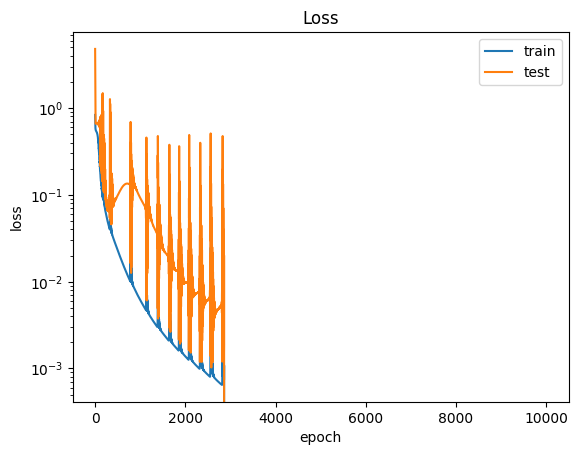

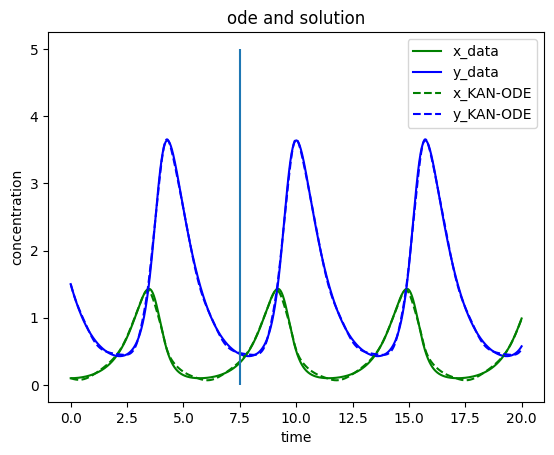

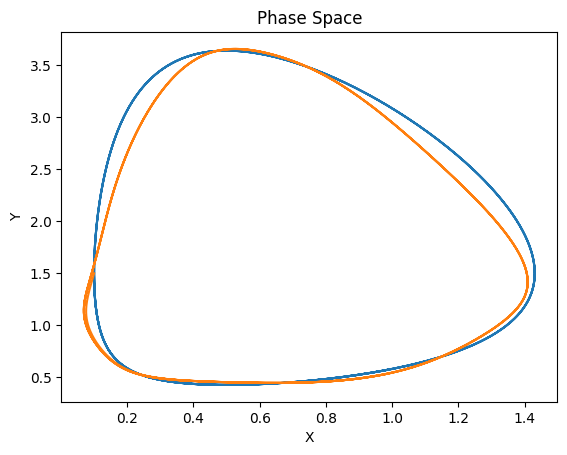

100%|██████████| 10000/10000 [6:47:01<00:00,  2.44s/it] 


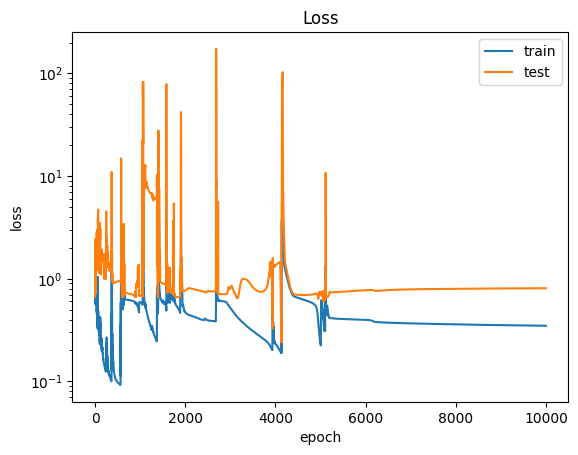

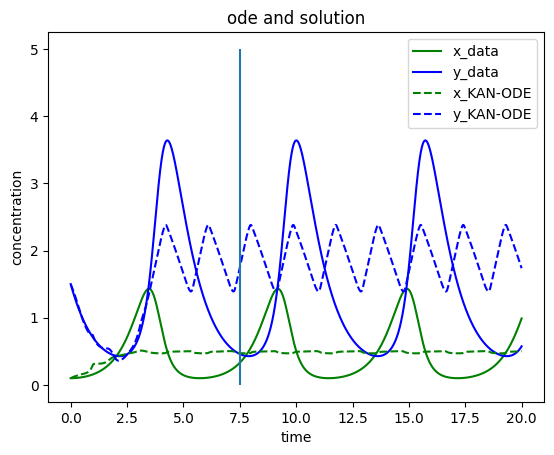

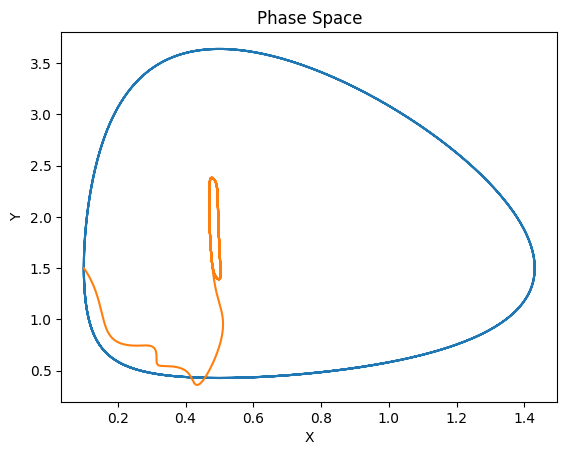

100%|██████████| 10000/10000 [2:51:19<00:00,  1.03s/it] 


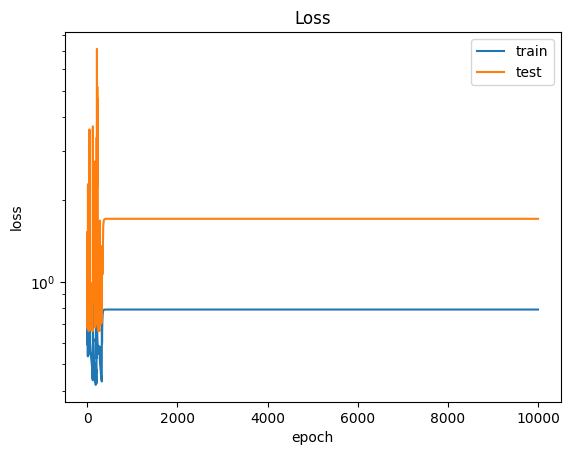

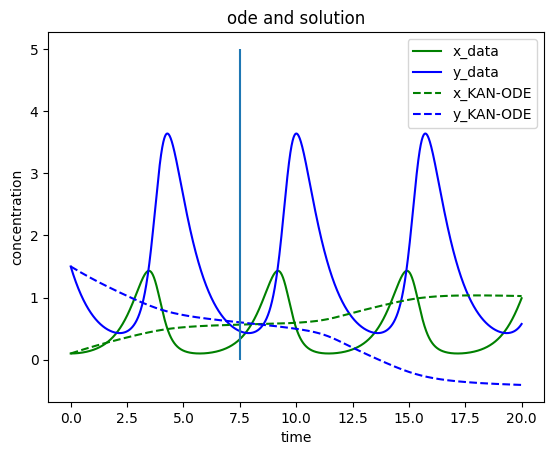

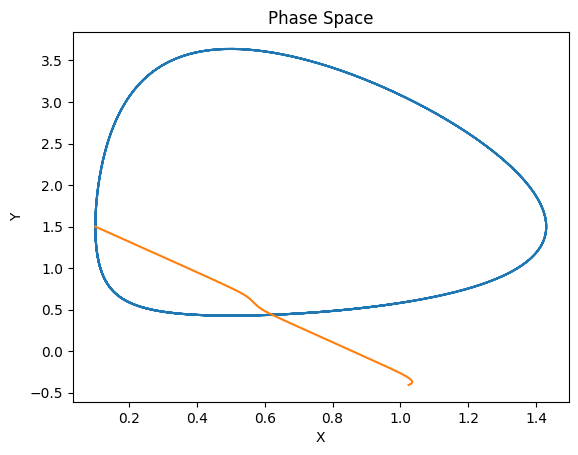

 87%|████████▋ | 8678/10000 [4:12:13<38:25,  1.74s/it]  


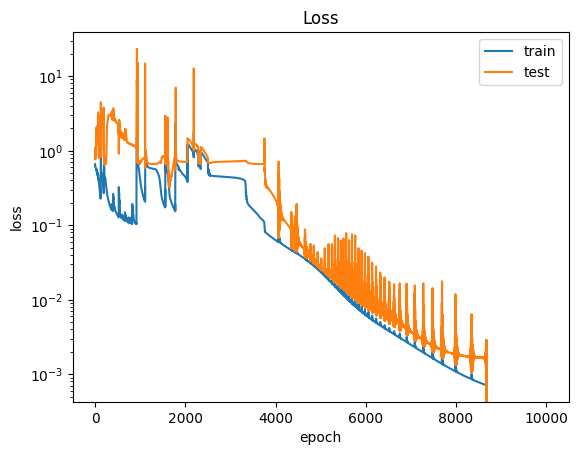

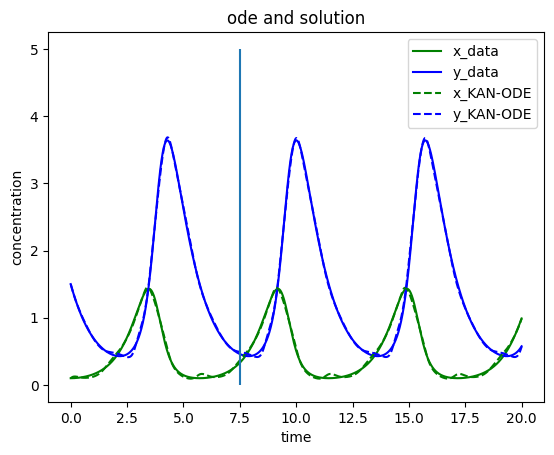

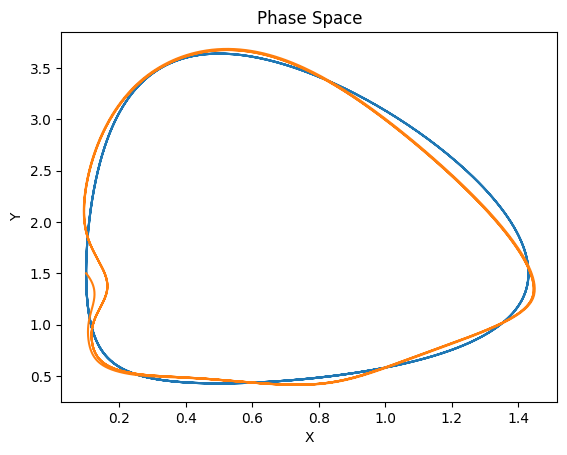

 52%|█████▏    | 5154/10000 [3:21:49<3:09:45,  2.35s/it]


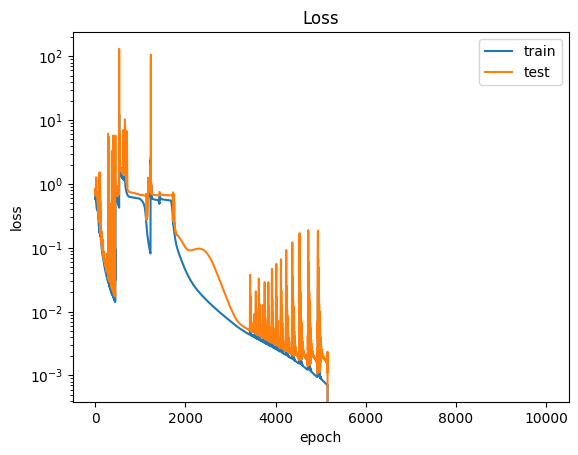

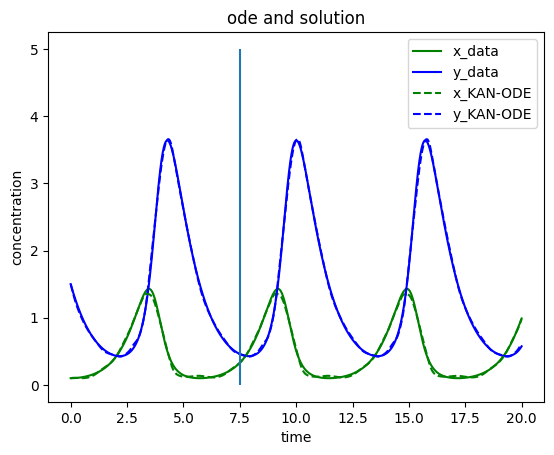

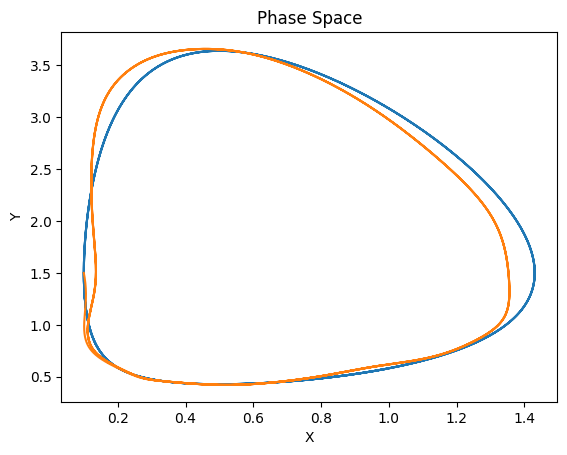

 20%|██        | 2017/10000 [56:45<3:44:37,  1.69s/it]


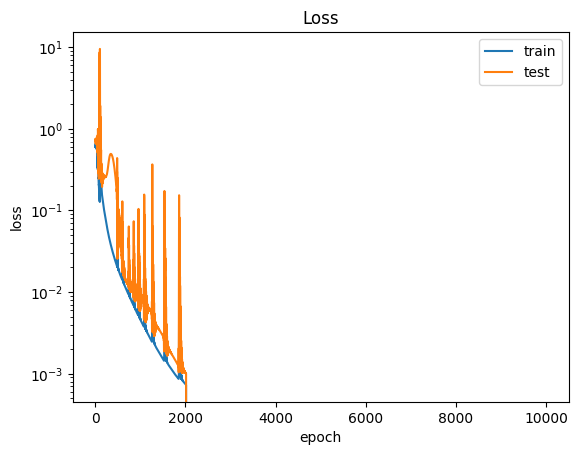

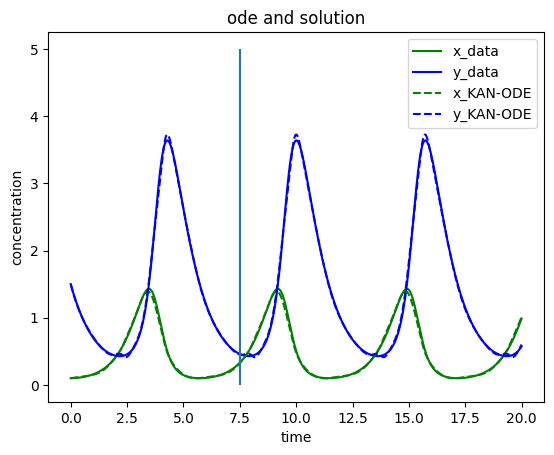

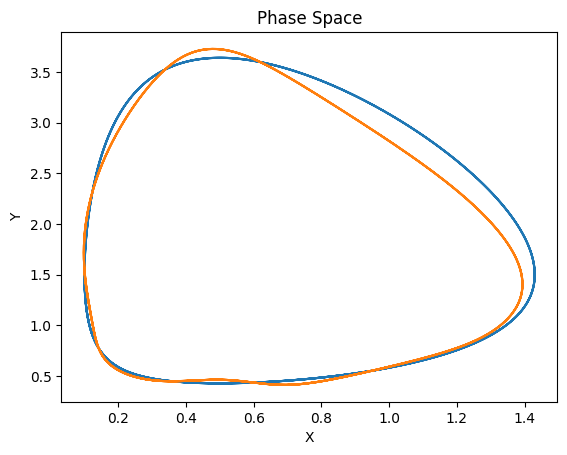

 35%|███▌      | 3531/10000 [2:45:00<5:02:17,  2.80s/it]


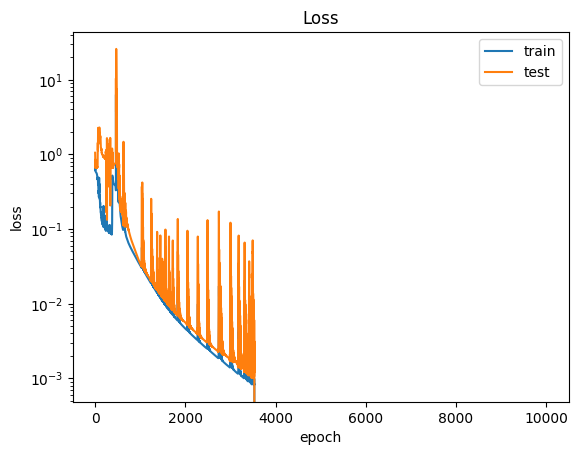

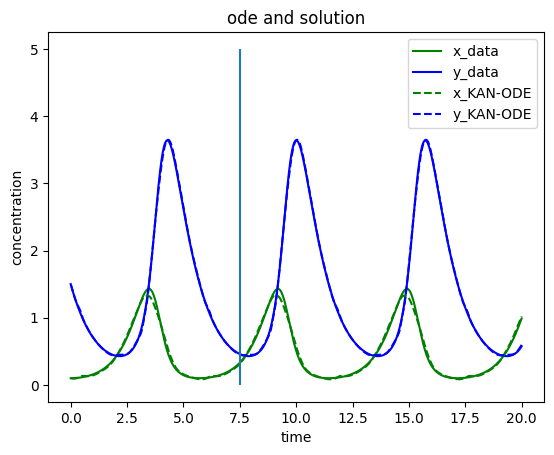

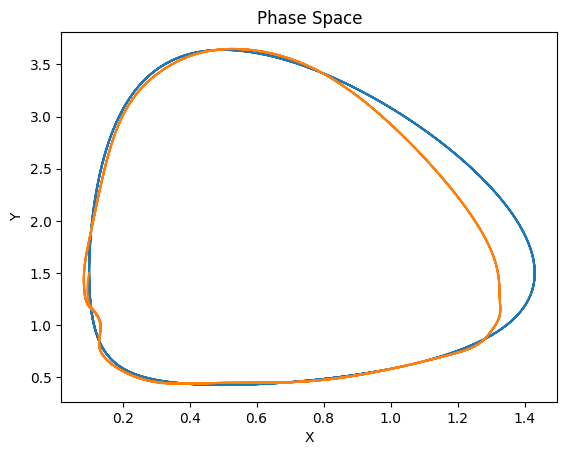

  8%|▊         | 770/10000 [30:45<6:08:36,  2.40s/it]


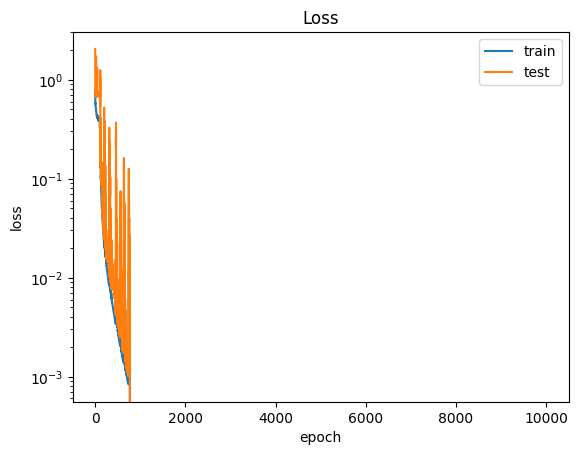

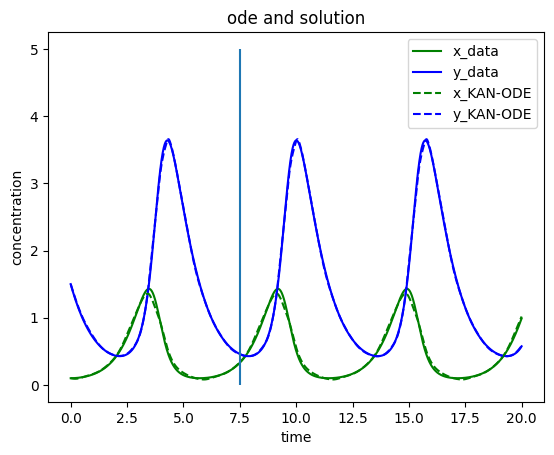

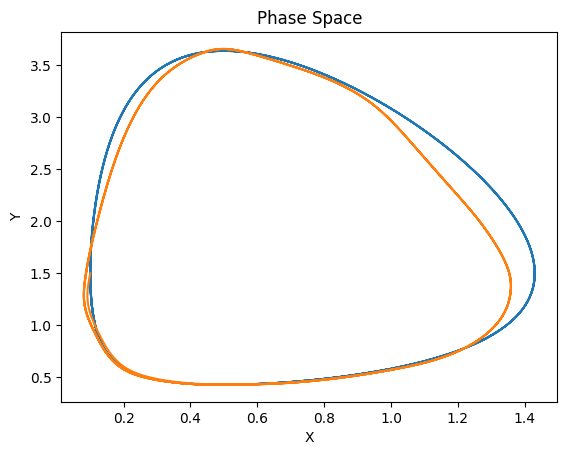

 53%|█████▎    | 5309/10000 [3:29:48<3:05:22,  2.37s/it]


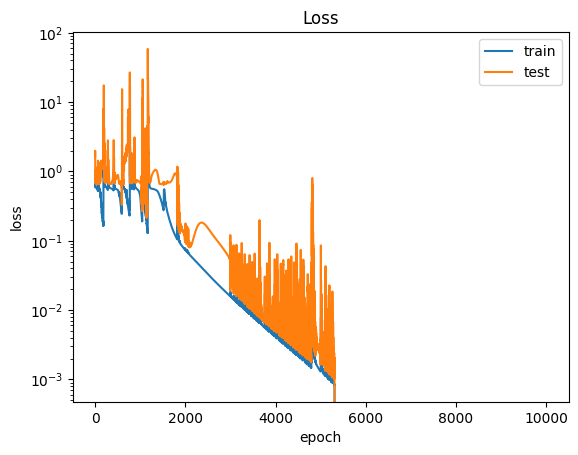

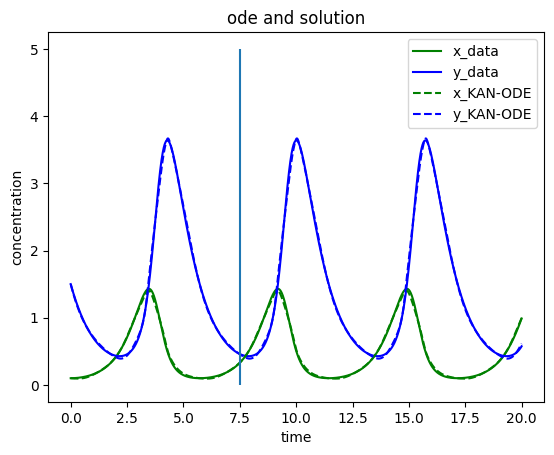

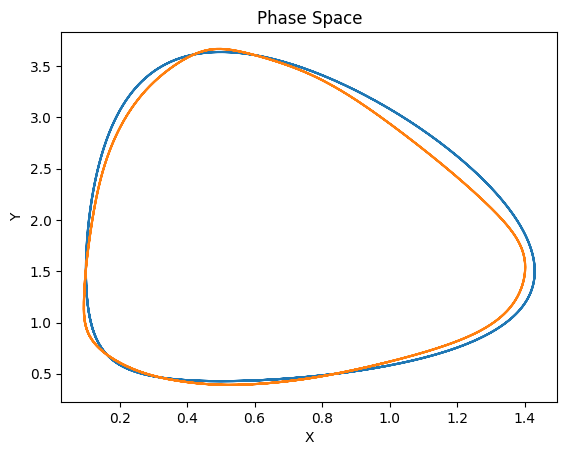

In [4]:
for kanODE in kanODEs:
    try:
        saveDirectory = os.path.join(module_path, "savedModels", "structureSweep1", f"layerSize-{kanODE.model.layers[0].outdim}_layerCount-{len(kanODE.model.layers)-1}")
        os.makedirs(saveDirectory)
        kanODE.train(-1, saveDirectory=saveDirectory, saveCooldown=100, evalThreshold=10**-3)
        _, solution = kanODE.test()
        kanODE.plotLoss("Loss")
        kanODE.plotODE("ode and solution", solution[:, 0, :])
        kanODE.plotPhaseSpace("Phase Space", solution[:, 0, :])
    except:
        continue